In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patches
from matplotlib.colors import Normalize, BoundaryNorm
from scipy import stats
from scipy.optimize import curve_fit

import paths
from utils import get_color_list, get_bin_centers
from mwm_sample import abundance_ratio

plt.style.use(paths.styles / 'notebook.mplstyle')

In [2]:
mwm_rgb = pd.read_csv(paths.data / 'MWM' / 'MWM_RGB.csv')
mwm_rgb

/var/folders/_s/lknhlnjn1g1cj388brpgztf80000gn/T/ipykernel_70022/610113364.py:1: DtypeWarning: Columns (44) have mixed types. Specify dtype option on import or set low_memory=False.
  mwm_rgb = pd.read_csv(paths.data / 'MWM' / 'MWM_RGB.csv')



,sdss_id,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,...,e,parallax,ra_y,dec_y,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,ruwe,z_max,Rg
0,54381291,NaN,421495278551818624,421495278551818624,403218924,16384,tic_v8,25,27021597850714872,4291430952,...,NaN,0.132960,4.281347,56.316985,14.488654,15.619171,13.432241,1.114031,NaN,NaN
1,54381397,NaN,421505552113500800,421505552113500800,369831391,16384,tic_v8,25,27021597850723334,4291439436,...,NaN,0.229285,4.066874,56.422930,13.574258,14.658734,12.552815,1.032361,NaN,NaN
2,54381405,NaN,421506067509558016,421506067510359808,369831290,16384,tic_v8,25,27021597850724078,4291440182,...,NaN,0.287407,4.092194,56.472699,12.253111,13.457909,11.174816,1.058355,NaN,NaN
3,54381758,2M00204981+5625073,421540152367477248,421540152367477248,403307163,16385,gaia_dr3_source,31,63050394783216344,4291448641,...,NaN,0.137260,5.207570,56.418666,13.690668,14.897005,12.616476,1.025529,NaN,NaN
4,54381959,2M00224114+5636475,421557607115380608,421557607115380608,403393455,16025,gaia_dr3_source,31,63050394783222145,4291878516,...,0.176938,0.534588,5.671459,56.613157,11.369628,12.251155,10.450673,1.183852,0.205899,8.531358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233282,129060884,2M09110058-4849577,5326021096449688064,5326021096449688064,364057991,172356,gaia_dr3_source,31,63050395875982757,5802300216,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
233283,129060885,2M08333243-3911278,5529360241405866752,5529360241405866752,185021879,160694,gaia_dr3_source,31,63050395950945615,5800869040,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
233284,129060909,2M13582184-6202236,5866253799616922112,5866253799616922112,325588166,185382,gaia_dr3_source,31,63050396108514375,5632820971,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
233285,129060928,2M18243818-1635046,4096998479419908352,4096998479419908352,333258955,126601,gaia_dr3_source,31,63050395404576784,5037812306,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [64]:
mwm_rgb_local = mwm_rgb[
    (mwm_rgb['gal_r'] >= 7) &
    (mwm_rgb['gal_r'] < 9) &
    (mwm_rgb['gal_z'].abs() < 2) &
    (mwm_rgb['logg'] < 3.5)
]
mwm_rgb_local

,sdss_id,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,...,e,parallax,ra_y,dec_y,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,ruwe,z_max,Rg
5,54381962,NaN,421557744554456064,421557744554456064,403393481,16025,tic_v8,25,27021597851161095,4291878605,...,0.023527,0.821440,5.742822,56.604244,11.354103,12.103177,10.509450,1.051452,0.107297,8.766076
19,54382295,NaN,421589183715747968,421589183715747968,327577724,16024,tic_v8,25,27021597850733418,4291449550,...,0.082842,0.621352,4.838551,56.535746,12.989830,13.689755,12.176354,1.093702,0.253124,8.840263
27,54382700,2M00200721+5700122,421625909974353280,421625914277199872,406762101,15668,gaia_dr3_source,31,63050394783245110,4291624784,...,0.126596,0.953161,5.030085,57.003410,11.962486,12.695877,11.121562,6.407218,0.183795,7.756411
60,54383757,2M00290801+5640111,421706109904337024,421706109904337024,320047050,16027,gaia_dr3_source,31,63050394783273185,4291910754,...,0.098802,0.726696,7.283335,56.669774,12.007926,12.807559,11.132788,4.010105,0.136858,8.739005
73,54384509,2M00271056+5654556,421762352496488832,421762352496488832,319844954,15670,gaia_dr3_source,31,63050394783292573,4291900981,...,0.098081,0.637712,6.794001,56.915434,12.128599,12.845614,11.306450,1.005274,0.154093,8.455453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233261,129060727,2M10455986-6014078,5254217214725965184,5254217214725965184,391155000,183791,gaia_dr3_source,31,63050395843775337,5771618716,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
233266,129060768,2M09150089-4756448,5326450696258684032,5326450696258684032,461741387,171468,gaia_dr3_source,31,63050395876069826,5802236276,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
233268,129060777,2M09120875-4832413,5326054081799907712,5326054081799907712,372916511,171914,gaia_dr3_source,31,63050395875989157,5802232075,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
233279,129060864,2M09093978-4751104,5326886175877017088,5326886175877017088,74380758,171016,gaia_dr3_source,31,63050395876148699,5802260041,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


/var/folders/_s/lknhlnjn1g1cj388brpgztf80000gn/T/ipykernel_70022/2417272515.py:16: RuntimeWarning: invalid value encountered in divide
  axs[1].hist(bins[:-1], bins, weights=flag_hist / all_hist)



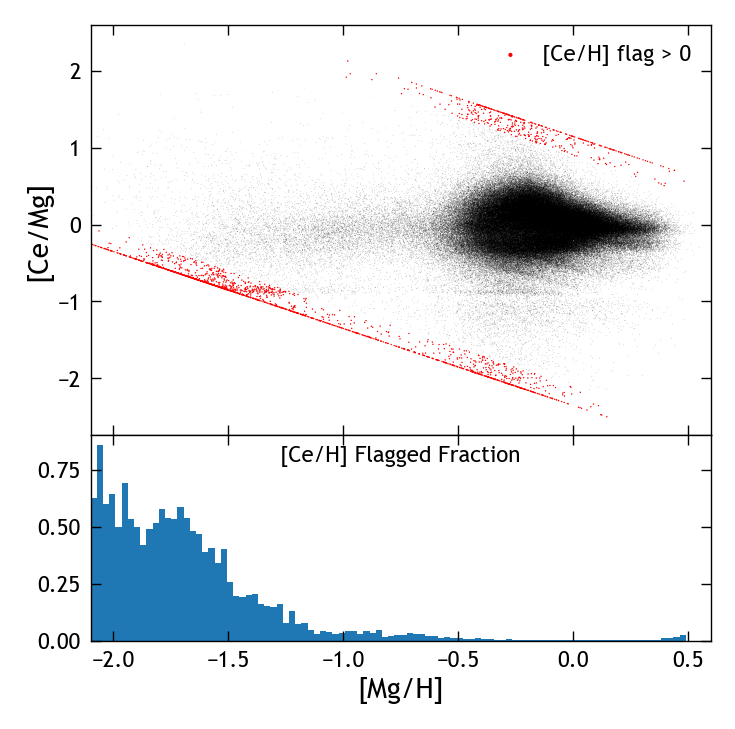

In [74]:
fig, axs = plt.subplots(2, sharex=True, gridspec_kw={'hspace': 0, 'height_ratios': (2, 1)})
xlim = (-2.1, 0.6)
kwargs = dict(s=0.3, marker='.', rasterized=True, edgecolor='none')
axs[0].scatter(mwm_rgb['mg_h'], mwm_rgb['ce_mg'], c='k', alpha=0.3, **kwargs)
ce_flags = mwm_rgb[mwm_rgb['ce_h_flags'] > 0]
kwargs['s'] = 1
axs[0].scatter(ce_flags['mg_h'], ce_flags['ce_mg'], c='r', label='[Ce/H] flag > 0', **kwargs)
axs[0].set_xlim(xlim)
# axs[0].set_ylim((-1, 1))
axs[0].set_ylabel('[Ce/Mg]')
axs[0].legend(markerscale=3)

bins = 100
flag_hist, bins = np.histogram(ce_flags['mg_h'], range=xlim, bins=bins)
all_hist, bins = np.histogram(mwm_rgb['mg_h'], range=xlim, bins=bins)
axs[1].hist(bins[:-1], bins, weights=flag_hist / all_hist)
axs[1].set_xlabel('[Mg/H]')
axs[1].text(0.5, 0.95, '[Ce/H] Flagged Fraction', ha='center', va='top', transform=axs[1].transAxes)

plt.show()

/var/folders/_s/lknhlnjn1g1cj388brpgztf80000gn/T/ipykernel_70022/3827790637.py:16: RuntimeWarning: invalid value encountered in divide
  axs[1].hist(bins[:-1], bins, weights=flag_hist / all_hist)



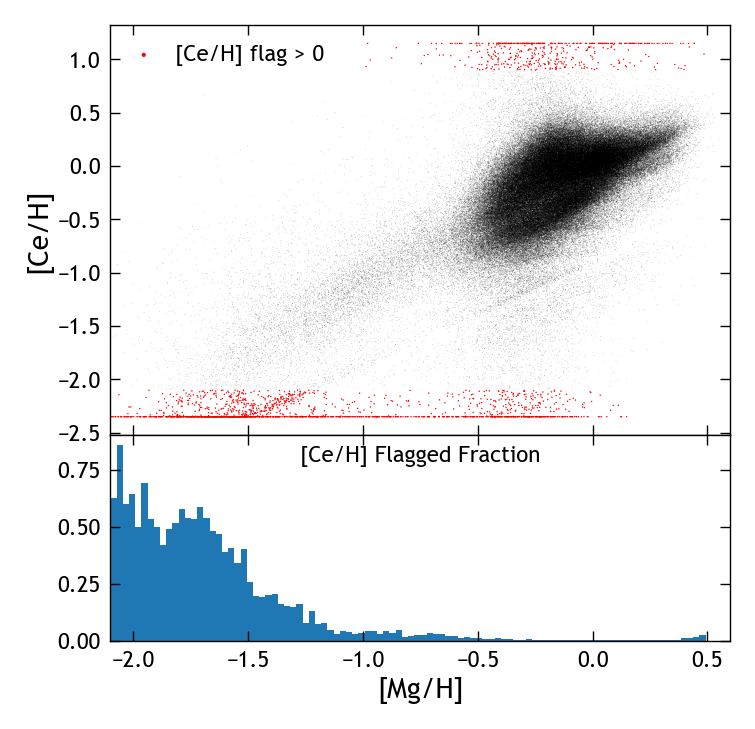

In [77]:
fig, axs = plt.subplots(2, sharex=True, gridspec_kw={'hspace': 0, 'height_ratios': (2, 1)})
xlim = (-2.1, 0.6)
kwargs = dict(s=0.3, marker='.', rasterized=True, edgecolor='none')
axs[0].scatter(mwm_rgb['mg_h'], mwm_rgb['ce_h'], c='k', alpha=0.3, **kwargs)
ce_flags = mwm_rgb[mwm_rgb['ce_h_flags'] > 0]
kwargs['s'] = 1
axs[0].scatter(ce_flags['mg_h'], ce_flags['ce_h'], c='r', label='[Ce/H] flag > 0', **kwargs)
axs[0].set_xlim(xlim)
# axs[0].set_ylim((-1, 1))
axs[0].set_ylabel('[Ce/H]')
axs[0].legend(markerscale=3)

bins = 100
flag_hist, bins = np.histogram(ce_flags['mg_h'], range=xlim, bins=bins)
all_hist, bins = np.histogram(mwm_rgb['mg_h'], range=xlim, bins=bins)
axs[1].hist(bins[:-1], bins, weights=flag_hist / all_hist)
axs[1].set_xlabel('[Mg/H]')
axs[1].text(0.5, 0.95, '[Ce/H] Flagged Fraction', ha='center', va='top', transform=axs[1].transAxes)

plt.show()

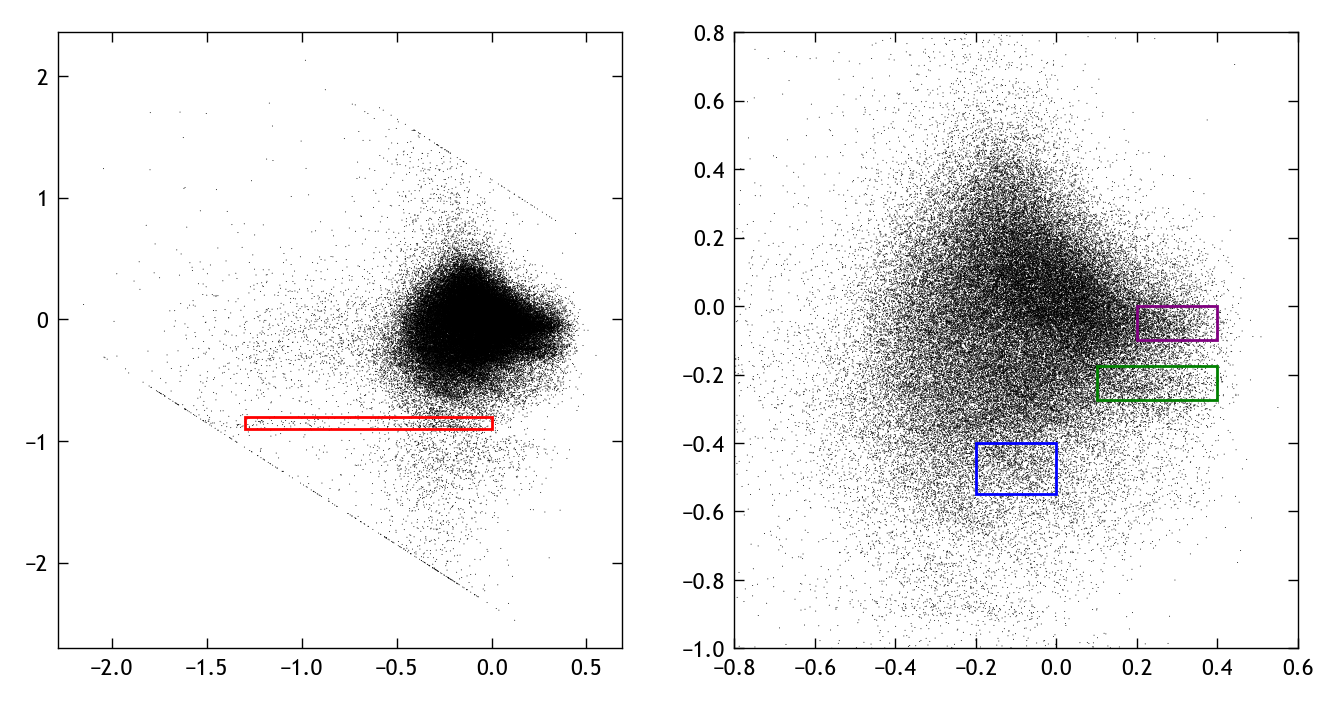

In [67]:
kwargs = dict(linewidth=1, facecolor='none')

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].scatter(mwm_rgb_local['mg_h'], mwm_rgb_local['ce_mg'],
           s=0.5, marker='.', rasterized=True, edgecolor='none', c='k')
r1 = patches.Rectangle((-1.3, -0.9), 1.3, 0.1, edgecolor='r', **kwargs)
axs[0].add_patch(r1)

axs[1].scatter(mwm_rgb_local['mg_h'], mwm_rgb_local['ce_mg'],
           s=0.5, marker='.', rasterized=True, edgecolor='none', c='k')
r2 = patches.Rectangle((-0.2, -0.55), 0.2, 0.15, edgecolor='b', **kwargs)
axs[1].add_patch(r2)
r3 = patches.Rectangle((0.1, -0.275), 0.3, 0.1, edgecolor='g', **kwargs)
axs[1].add_patch(r3)
r4 = patches.Rectangle((0.2, -0.1), 0.2, 0.1, edgecolor='purple', **kwargs)
axs[1].add_patch(r4)

axs[1].set_xlim((-0.8, 0.6))
axs[1].set_ylim((-1, 0.8))
plt.show()

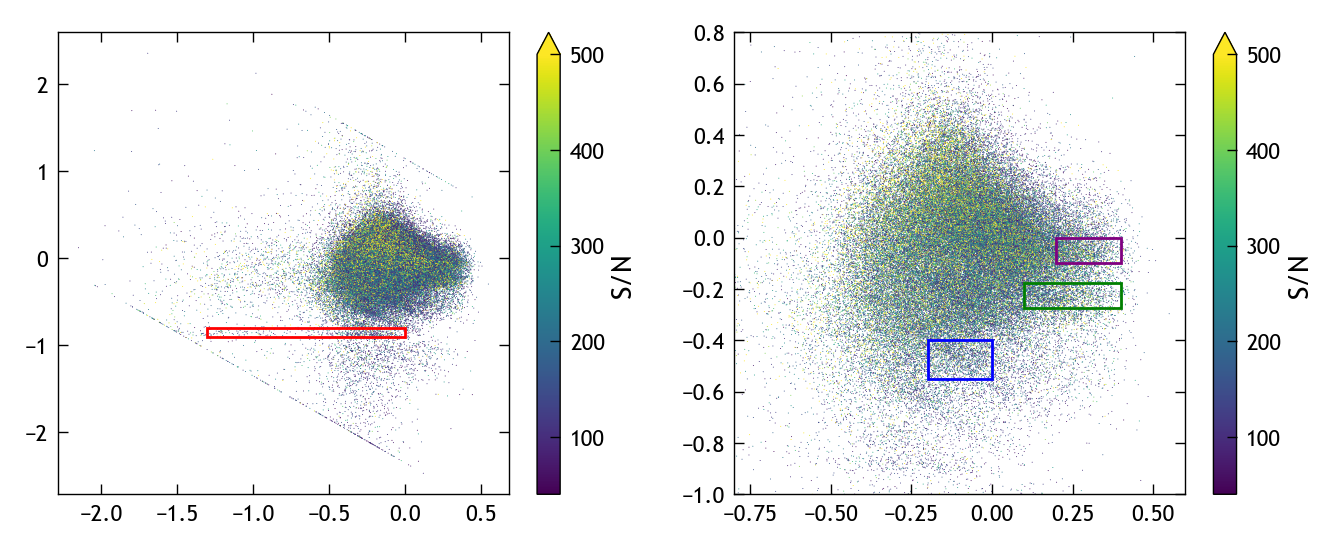

In [49]:
kwargs = dict(linewidth=1, facecolor='none')
color = mwm_rgb_local['snr']
vmax = 500

fig, axs = plt.subplots(1, 2, figsize=(8, 3))
pc1 = axs[0].scatter(mwm_rgb_local['mg_h'], mwm_rgb_local['ce_mg'],
           s=0.5, marker='.', rasterized=True, edgecolor='none', 
           c=color, vmax=vmax)
fig.colorbar(pc1, ax=axs[0], label='S/N', extend='max')

r1 = patches.Rectangle((-1.3, -0.9), 1.3, 0.1, edgecolor='r', **kwargs)
axs[0].add_patch(r1)

pc2 = axs[1].scatter(mwm_rgb_local['mg_h'], mwm_rgb_local['ce_mg'],
           s=0.5, marker='.', rasterized=True, edgecolor='none', 
           c=color, vmax=vmax)
fig.colorbar(pc2, ax=axs[1], label='S/N', extend='max')
r2 = patches.Rectangle((-0.2, -0.55), 0.2, 0.15, edgecolor='b', **kwargs)
axs[1].add_patch(r2)
r3 = patches.Rectangle((0.1, -0.275), 0.3, 0.1, edgecolor='g', **kwargs)
axs[1].add_patch(r3)
r4 = patches.Rectangle((0.2, -0.1), 0.2, 0.1, edgecolor='purple', **kwargs)
axs[1].add_patch(r4)

axs[1].set_xlim((-0.8, 0.6))
axs[1].set_ylim((-1, 0.8))
plt.show()

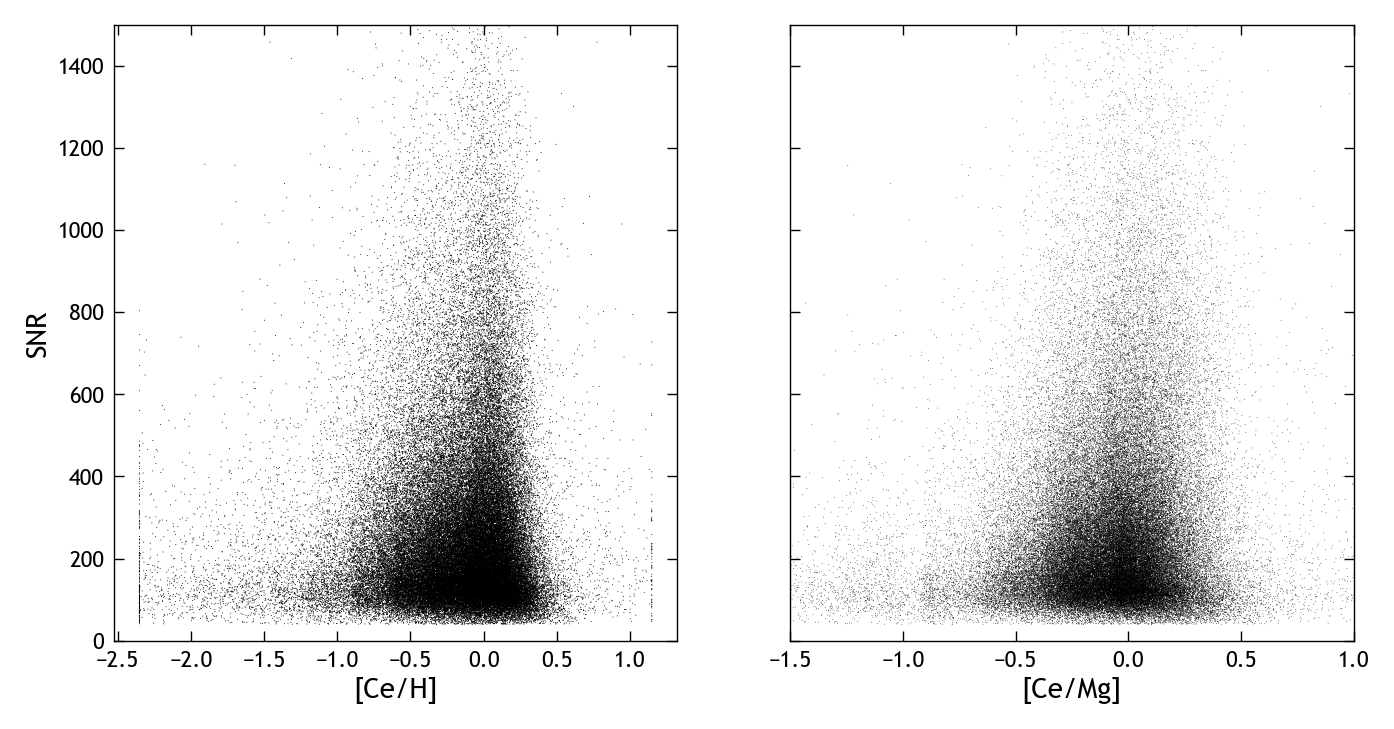

In [55]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
axs[0].scatter(mwm_rgb_local['ce_h'], mwm_rgb_local['snr'], 
           s=0.5, marker='.', rasterized=True, edgecolor='none', c='k')
axs[0].set_ylabel('SNR')
axs[0].set_xlabel('[Ce/H]')
axs[0].set_ylim((0, 1500))

axs[1].scatter(mwm_rgb_local['ce_mg'], mwm_rgb_local['snr'], 
           s=0.3, marker='.', rasterized=True, edgecolor='none', c='k')
axs[1].set_xlabel('[Ce/Mg]')
axs[1].set_xlim((-1.5, 1))
plt.show()

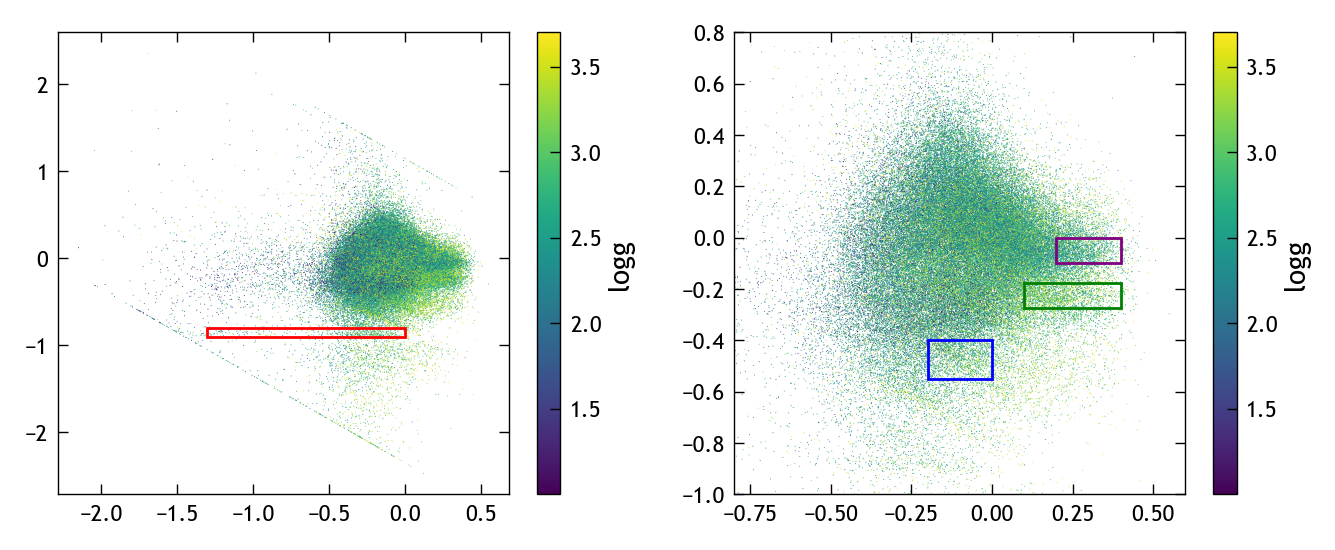

In [61]:
kwargs = dict(linewidth=1, facecolor='none')
color_kwargs = dict(c=mwm_rgb_local['logg'])

fig, axs = plt.subplots(1, 2, figsize=(8, 3))
pc1 = axs[0].scatter(mwm_rgb_local['mg_h'], mwm_rgb_local['ce_mg'],
           s=0.5, marker='.', rasterized=True, edgecolor='none', 
           **color_kwargs)
fig.colorbar(pc1, ax=axs[0], label='logg')

r1 = patches.Rectangle((-1.3, -0.9), 1.3, 0.1, edgecolor='r', **kwargs)
axs[0].add_patch(r1)

pc2 = axs[1].scatter(mwm_rgb_local['mg_h'], mwm_rgb_local['ce_mg'],
           s=0.5, marker='.', rasterized=True, edgecolor='none', 
           **color_kwargs)
fig.colorbar(pc2, ax=axs[1], label='logg')
r2 = patches.Rectangle((-0.2, -0.55), 0.2, 0.15, edgecolor='b', **kwargs)
axs[1].add_patch(r2)
r3 = patches.Rectangle((0.1, -0.275), 0.3, 0.1, edgecolor='g', **kwargs)
axs[1].add_patch(r3)
r4 = patches.Rectangle((0.2, -0.1), 0.2, 0.1, edgecolor='purple', **kwargs)
axs[1].add_patch(r4)

axs[1].set_xlim((-0.8, 0.6))
axs[1].set_ylim((-1, 0.8))
plt.show()

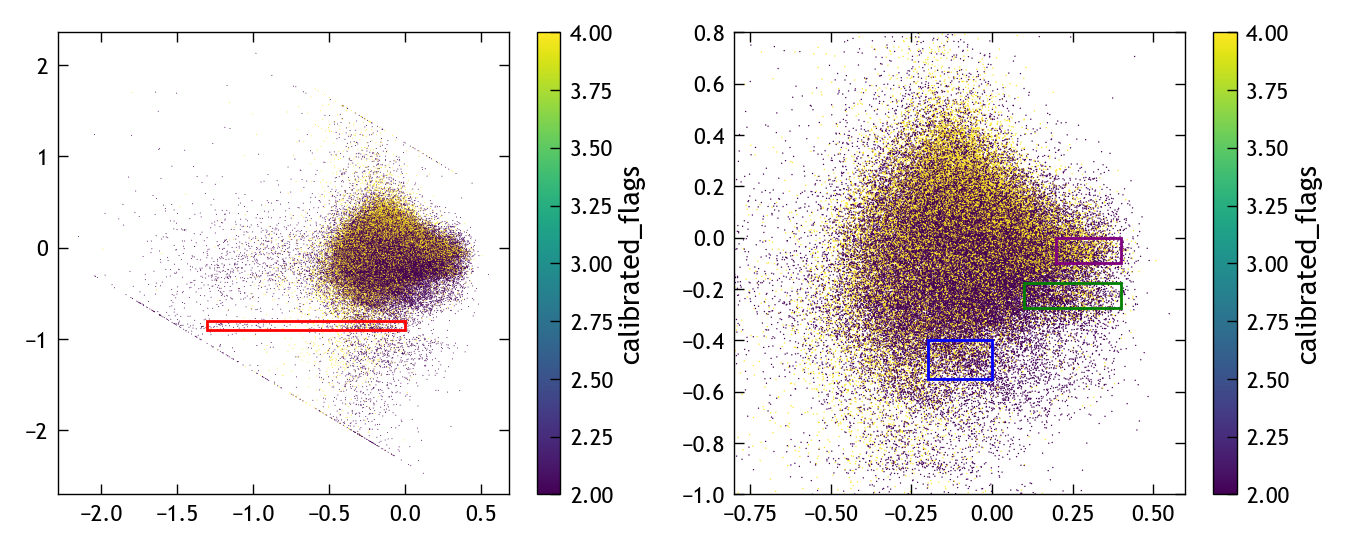

In [98]:
kwargs = dict(linewidth=1, facecolor='none')
color_col = 'calibrated_flags'
color_kwargs = dict(c=mwm_rgb_local[color_col])

fig, axs = plt.subplots(1, 2, figsize=(8, 3))
pc1 = axs[0].scatter(mwm_rgb_local['mg_h'], mwm_rgb_local['ce_mg'],
           s=0.5, marker='.', rasterized=True, edgecolor='none', 
           **color_kwargs)
fig.colorbar(pc1, ax=axs[0], label=color_col)

r1 = patches.Rectangle((-1.3, -0.9), 1.3, 0.1, edgecolor='r', **kwargs)
axs[0].add_patch(r1)

pc2 = axs[1].scatter(mwm_rgb_local['mg_h'], mwm_rgb_local['ce_mg'],
           s=1, marker='.', rasterized=True, edgecolor='none', 
           **color_kwargs)
fig.colorbar(pc2, ax=axs[1], label=color_col)
r2 = patches.Rectangle((-0.2, -0.55), 0.2, 0.15, edgecolor='b', **kwargs)
axs[1].add_patch(r2)
r3 = patches.Rectangle((0.1, -0.275), 0.3, 0.1, edgecolor='g', **kwargs)
axs[1].add_patch(r3)
r4 = patches.Rectangle((0.2, -0.1), 0.2, 0.1, edgecolor='purple', **kwargs)
axs[1].add_patch(r4)

axs[1].set_xlim((-0.8, 0.6))
axs[1].set_ylim((-1, 0.8))
plt.show()